In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np

import matplotlib.pyplot as plt
from time import time
from mad.configs.ballistic_objects import titan_stage_1, titan_stage_2, B53_warhead
from mad.configs.planets import EARTH_SETTINGS
from mad.objs.planets import Planet, PlanetConfig
from mad.objs.missiles import BallisticMissileConfig, MissileStage, MissileStageConfig, BallisticMissile, Payload, PayloadConfig
from mad.objs.guidances import TabulatedBallistic, RCSGuidance, ProportionalNavigation
from mad.logger import SourceLogger
from mad.utils import extract_history


logger = SourceLogger()

In [3]:
EARTH_SETTINGS["position"] = [0.0, 0.0]

earth = Planet(PlanetConfig(**EARTH_SETTINGS))
launchpad = earth.create_2D_point(name="Launchpad", altitude=10)
target = earth.create_2D_point_at_distance(launchpad, distance_km=8_000, name="Target")

earth

Planet Earth at [0. 0. 0.]
Mass 5.97e+24 kg, Radius 6371.0 km.
Gravity at surface: -9.82 m/s^2
Orbital velocity: 7909.55 m/s
Escape velocity: 11185.79 m/s

In [9]:
stage1 = MissileStage(MissileStageConfig(**titan_stage_1))
stage2 = MissileStage(MissileStageConfig(**titan_stage_2))

missile_guidance = TabulatedBallistic(planet=earth, target=target, ballistic_table_path="B53_warhead_fine")

warhead_guidance = ProportionalNavigation(planet=earth, target=target, N=10.0)
# warhead_guidance = TabulatedBallistic(planet=earth, target=target, ballistic_table_path="B53_warhead_-90_90")
payload_cfg = PayloadConfig(**B53_warhead)
payload_cfg.guidance = warhead_guidance
payload_cfg.mass = 4000.0
payload_cfg.RCS_thrust = 0.0

missile_cfg = BallisticMissileConfig(stages=[stage1, stage2], guidance=missile_guidance, payload=payload_cfg)
titan = BallisticMissile(position=launchpad.position.copy(), cfg=missile_cfg, name="Titan I")

titan

BallisticMissile Titan I, active.
Stages: Stage1, Stage2.
Available deltaV: 12039.61 m/s.
Burned Fraction: 0.00.

In [10]:
dt = 1
max_time = 20_000
active_objs = [titan]
t = 0.0
logger["Simulation"].info("Starting simulation.")
start = time()
while (t < max_time) and any(obj.active for obj in active_objs):
    new_objects = []

    for obj in active_objs[:]:

        if not obj.active:
            continue

        sim_update = obj.update(dt)

        if sim_update is not None:
            for new_object in sim_update:
                logger["Simulation"].info(f"{new_object.name} added to Simulation.")
                new_objects.append(new_object)

        if not obj.active:
            continue
        obj.integrate(dt, earth)

    active_objs.extend(new_objects)
    t += dt
stop = time()
logger["Simulation"].info(f"Simulation ended at t={t:.2f} seconds. Took {stop - start:.2f} seconds of real time.")
results = extract_history(active_objs, planet=earth)

19:01:17 | INFO     | Simulation   | Starting simulation.
19:01:18 | INFO     | Missile      | Stage1 ran out of propellant at 110.00.
19:01:18 | INFO     | Missile      | Titan I - Stage1 separated at 110.00.
19:01:18 | INFO     | Simulation   | Stage1 added to Simulation.
19:01:19 | DEBUG    | Guidance     | Target range 7372835.86 reached at Table index: 177388, table values: {'altitude_m': '330000.00', 'velocity_m_s': '6400.00', 'gamma_rad': '0.49', 'range_rad': '1.20'}.
19:01:19 | DEBUG    | Guidance     | Switch range error: -245.45 km, gamma error: -0.00 rad.
19:01:19 | INFO     | Missile      | Titan I switched to ballistic phase at 324.00.
19:01:19 | INFO     | Missile      | Titan I released payload B53_Warhead at 324.00.
19:01:19 | INFO     | Missile      | Titan I - Stage2 separated at 324.00.
19:01:19 | INFO     | Missile      | Titan I inactivated at 324.00.
19:01:19 | INFO     | Simulation   | B53_Warhead added to Simulation.
19:01:19 | INFO     | Simulation   | Stage2 a

/tmp/ipykernel_22994/2789105891.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  a.legend()


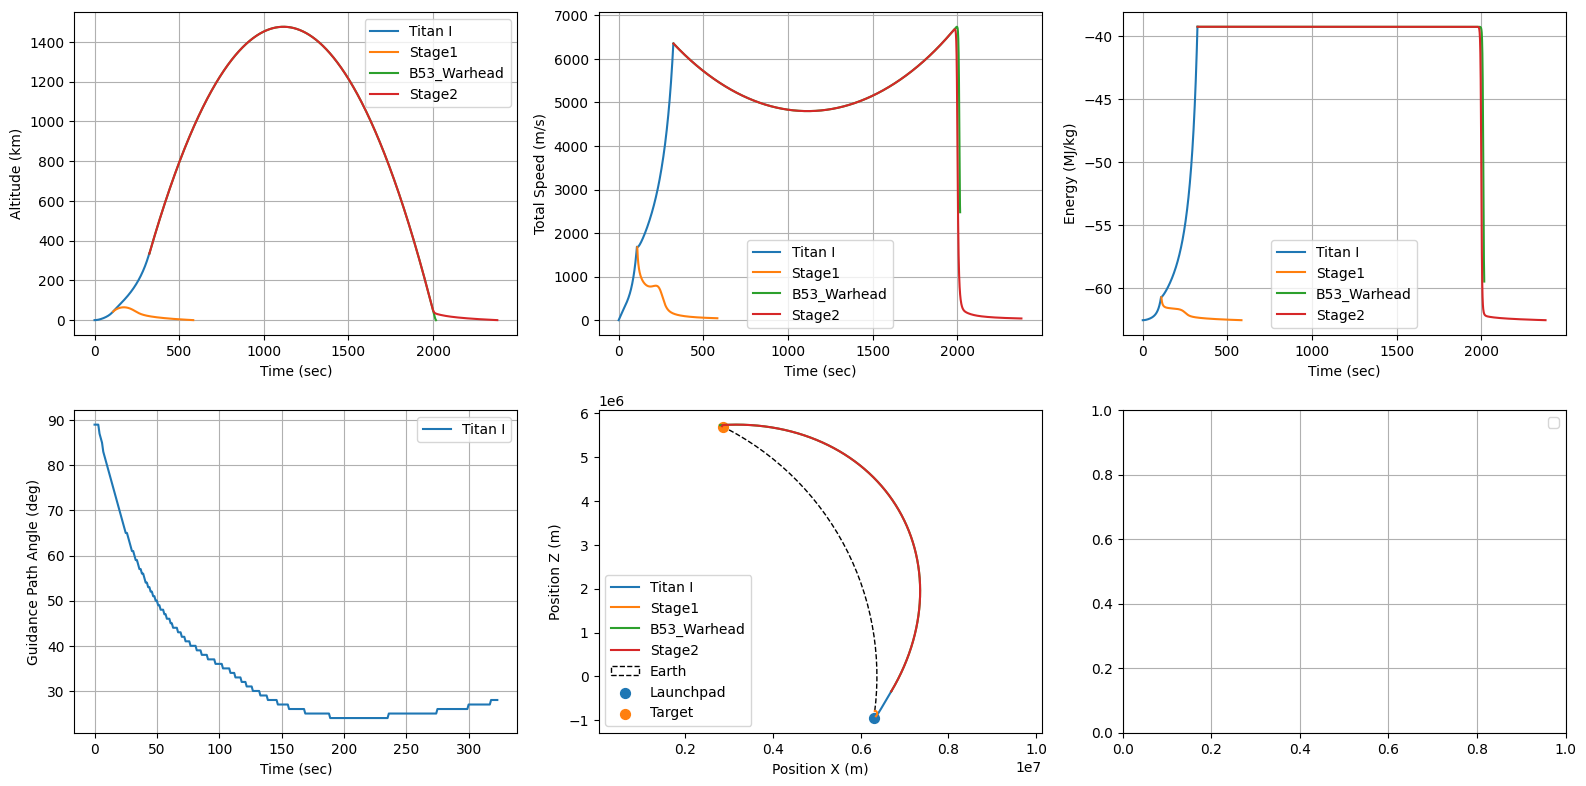

In [11]:
fig, ax = plt.subplots(ncols=3, nrows=2, figsize=(16, 8))
ax = ax.ravel()

for obj, result in results.items():

    ax[0].plot(result["time"], result["altitude"] / 1000, label=obj)
    ax[1].plot(result["time"], result["velocity"], label=obj)
    ax[2].plot(result["time"], result["energy"] / 1000_000, label=obj)
    if "gamma" in result and len(result["gamma"]) > 0:
        ax[3].plot(result["time"], np.degrees(result["gamma"]), label=obj)
    ax[4].plot(result["posx"], result["posz"], label=obj)


ax[0].set_xlabel("Time (sec)")
ax[0].set_ylabel("Altitude (km)")

ax[1].set_xlabel("Time (sec)")
ax[1].set_ylabel("Total Speed (m/s)")

ax[2].set_xlabel("Time (sec)")
ax[2].set_ylabel("Energy (MJ/kg)")

ax[3].set_xlabel("Time (sec)")
ax[3].set_ylabel("Guidance Path Angle (deg)")

earth.plot_2D_with_points(points = [launchpad, target], ax=ax[4], display_planet=True)
ax[4].set_xlabel("Position X (m)")
ax[4].set_ylabel("Position Z (m)")
ax[4].set_aspect("equal", adjustable="datalim")

for a in ax:
    a.grid()
    a.legend()


fig.tight_layout(pad=1.2)

In [19]:
f"Distance Impact to target: {earth.surface_distance(target, active_objs[2]) / 1000:.2f} km"

'Distance Impact to target: 212.45 km'